# Some ideas for the metrics

## Init and simulation

In [25]:
import os

import pandas as pd

from tqdm import tqdm

import leaspy
from leaspy.io.data import Data
from leaspy.models import JointModel
from leaspy.datasets import load_dataset

leaspy_root = os.path.dirname(leaspy.__file__)

data_path = os.path.join(leaspy_root, "datasets/data/simulated_data_for_joint.csv")

data = Data.from_dataframe(load_dataset("simulated_data_for_joint"), "joint")
df = data.to_dataframe()

display(df.head())
print(df.columns)

model = JointModel(name="test_model", nb_events=1)


,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,116,78.461,85.5,1,0.44444,0.04,0.0,0.0
1,116,78.936,85.5,1,0.60000,0.00,0.0,0.2
2,116,79.482,85.5,1,0.39267,0.04,0.0,0.2
3,116,79.939,85.5,1,0.58511,0.00,0.0,0.0
4,116,80.491,85.5,1,0.57044,0.00,0.0,0.0


Index(['ID', 'TIME', 'EVENT_TIME', 'EVENT_BOOL', 'Y0', 'Y1', 'Y2', 'Y3'], dtype='object')


In [26]:
model.fit(data, "mcmc_saem", seed=1312, n_iter=500, progress_bar=False)

/Users/jv.martini/Documents/leaspy/src/leaspy/models/time_reparametrized.py:288: UserWarning: You did not provide `source_dimension` hyperparameter for multivariate model, setting it to ⌊√dimension⌋ = 2.
  warnings.warn(


 ==> Setting seed to 1312

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 13s


In [27]:
# visit_params = {
#     "patient_number": df["ID"].nunique(),
#     "visit_type": "random",
#     "first_visit_mean": 0.0,
#     "first_visit_std": 0.4,
#     "time_follow_up_mean": 6,  
#     "time_follow_up_std": 1.2,
#     "distance_visit_mean": 2 / 12,
#     "distance_visit_std": 0.75 / 12,
#     "min_spacing_between_visits": 1,
# }

## Dynamic estimation of parameters (now included in joint_simulate directly if missing value)

In [28]:
visit_params = {
    "patient_number": 50,
    "visit_type": "random",
    "data": data
}

In [29]:
from IPython.utils import io

with io.capture_output() as captured:
    M = 100

    sims = []
    for m in tqdm(range(M), desc="Simulations"):
        df_s = model.simulate(
            algorithm="joint_simulate",
            features=["Y0", "Y1", "Y2", "Y3"],
            visit_parameters=visit_params,
        )
        sims.append(df_s.data.to_dataframe())

    display(sims[0].head())

## More sophisticated metrics

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

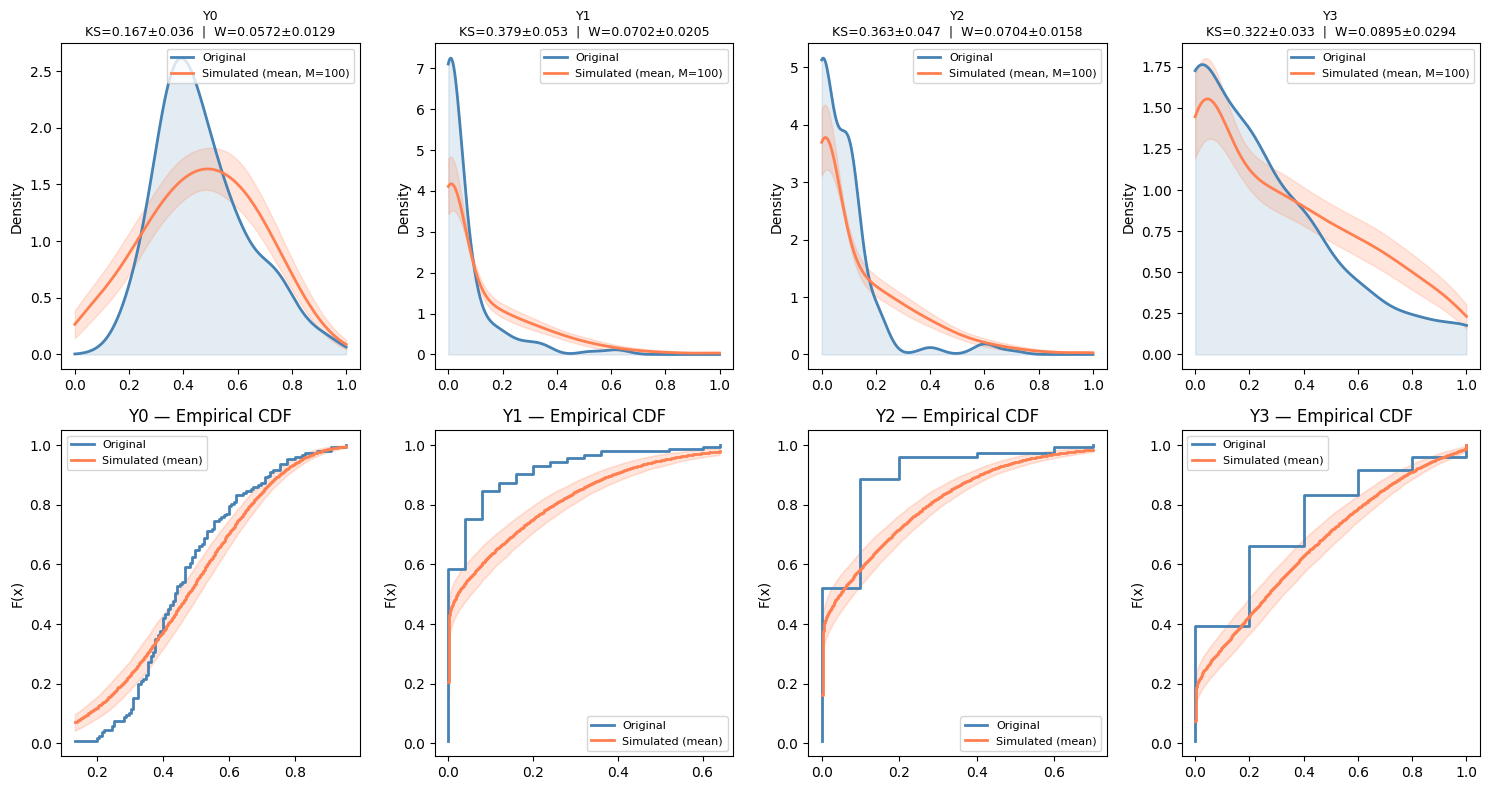

,Feature,KS mean,KS std,Wasserstein mean,Wasserstein std
0,Y0,0.1675,0.0360,0.0572,0.0129
1,Y1,0.3789,0.0528,0.0702,0.0205
2,Y2,0.3634,0.0471,0.0704,0.0158
3,Y3,0.3218,0.0333,0.0895,0.0294


In [31]:

feat_cols = ['Y0', 'Y1', 'Y2', 'Y3']

# Common x-grid (union of original range and all sims ranges)
x_grids = {}
for col in feat_cols:
    lo = min(df[col].min(), *(s[col].min() for s in sims))
    hi = max(df[col].max(), *(s[col].max() for s in sims))
    x_grids[col] = np.linspace(lo, hi, 300)

# Per-simulation KDE values and scalar metrics
kde_sim_all = {col: [] for col in feat_cols}
ks_all      = {col: [] for col in feat_cols}
wass_all    = {col: [] for col in feat_cols}

for df_s in sims:
    for col in feat_cols:
        a = df[col].dropna().values
        b = df_s[col].dropna().values
        kde_sim_all[col].append(stats.gaussian_kde(b)(x_grids[col]))
        ks_all[col].append(ks_2samp(a, b)[0])
        wass_all[col].append(wasserstein_distance(a, b))

fig, axes = plt.subplots(2, len(feat_cols), figsize=(15, 8))
summary_rows = []

for col, ax_kde, ax_cdf in zip(feat_cols, axes[0], axes[1]):
    xs = x_grids[col]
    a  = df[col].dropna().values

    # KDE panel
    kde_orig = stats.gaussian_kde(a)
    ax_kde.plot(xs, kde_orig(xs), label='Original', color='steelblue', lw=2)
    ax_kde.fill_between(xs, kde_orig(xs), alpha=0.15, color='steelblue')

    kde_mat  = np.array(kde_sim_all[col])   # (M, 300)
    kde_mean = kde_mat.mean(axis=0)
    kde_std  = kde_mat.std(axis=0)
    ax_kde.plot(xs, kde_mean, label=f'Simulated (mean, M={M})', color='coral', lw=2)
    ax_kde.fill_between(xs, kde_mean - kde_std, kde_mean + kde_std, alpha=0.2, color='coral')

    ks_m,   ks_s   = np.mean(ks_all[col]),   np.std(ks_all[col])
    wass_m, wass_s = np.mean(wass_all[col]), np.std(wass_all[col])
    ax_kde.set_title(f'{col}\nKS={ks_m:.3f}±{ks_s:.3f}  |  W={wass_m:.4f}±{wass_s:.4f}', fontsize=9)
    ax_kde.legend(fontsize=8)
    ax_kde.set_ylabel('Density')

    # ECDF panel — mean ± std of simulated ECDFs on a common grid
    x_ecdf   = np.linspace(a.min(), a.max(), 300)
    arr_orig = np.sort(a)
    ys_orig  = np.arange(1, len(arr_orig) + 1) / len(arr_orig)
    ax_cdf.step(arr_orig, ys_orig, where='post', label='Original', color='steelblue', lw=2)

    ecdf_mat = np.array([
        np.interp(x_ecdf, np.sort(df_s[col].dropna().values),
                  np.arange(1, df_s[col].dropna().shape[0] + 1) / df_s[col].dropna().shape[0])
        for df_s in sims
    ])
    ecdf_mean = ecdf_mat.mean(axis=0)
    ecdf_std  = ecdf_mat.std(axis=0)
    ax_cdf.step(x_ecdf, ecdf_mean, where='post', label=f'Simulated (mean)', color='coral', lw=2)
    ax_cdf.fill_between(x_ecdf, ecdf_mean - ecdf_std, ecdf_mean + ecdf_std,
                        alpha=0.2, color='coral', step='post')
    ax_cdf.set_title(f'{col} — Empirical CDF')
    ax_cdf.set_ylabel('F(x)')
    ax_cdf.legend(fontsize=8)

    summary_rows.append({
        'Feature': col,
        'KS mean': round(ks_m, 4),   'KS std': round(ks_s, 4),
        'Wasserstein mean': round(wass_m, 4), 'Wasserstein std': round(wass_s, 4),
    })

plt.tight_layout()
plt.show()
display(pd.DataFrame(summary_rows))


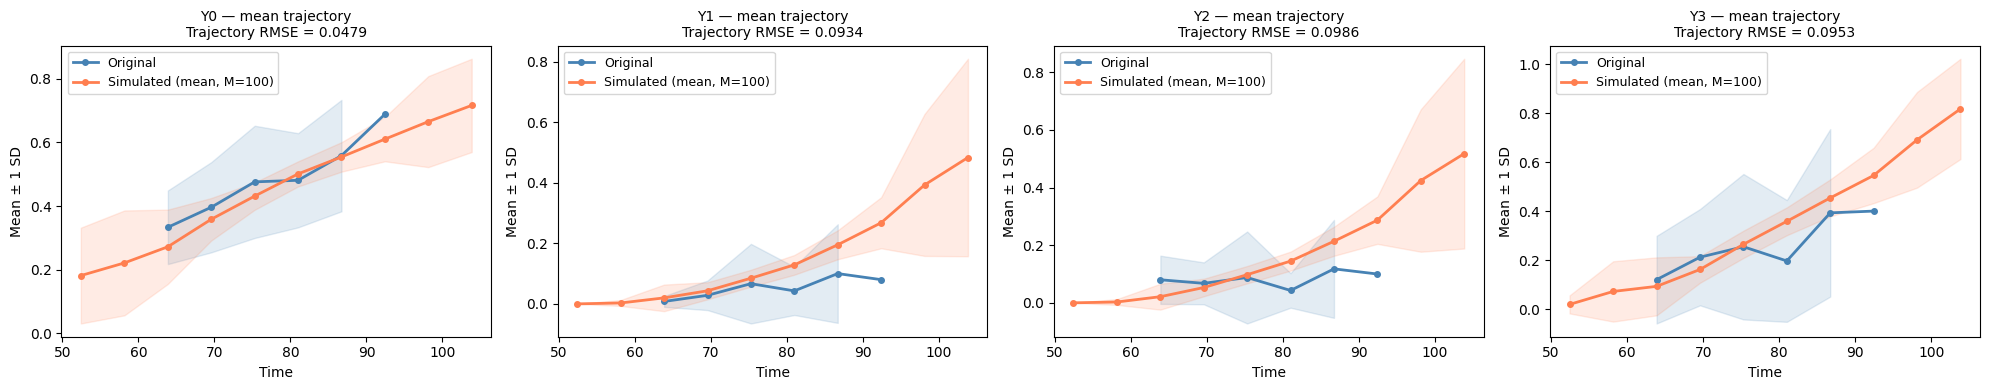

Trajectory RMSE per outcome: {'Y0': 0.0479, 'Y1': 0.0934, 'Y2': 0.0986, 'Y3': 0.0953}


In [32]:

def trajectory_comparison_avg(df, sims, outcome_cols, n_bins=10):
    all_times    = pd.concat([df['TIME']] + [s['TIME'] for s in sims])
    all_bin_cats = pd.cut(all_times, bins=n_bins).cat.categories
    bin_centers  = np.array([iv.mid for iv in all_bin_cats])

    fig, axes = plt.subplots(1, len(outcome_cols), figsize=(5 * len(outcome_cols), 4))
    if len(outcome_cols) == 1:
        axes = [axes]

    traj_metrics = {}
    for ax, col in zip(axes, outcome_cols):
        # Original bin means
        df2 = df.copy()
        df2['_bin'] = pd.cut(df2['TIME'], bins=all_bin_cats)
        m_orig  = df2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats).values
        sd_orig = df2.groupby('_bin', observed=False)[col].std().reindex(all_bin_cats).values

        ax.plot(bin_centers, m_orig, marker='o', ms=4, lw=2, label='Original', color='steelblue')
        ax.fill_between(bin_centers,
                        np.where(np.isnan(m_orig - sd_orig), np.nan, m_orig - sd_orig),
                        np.where(np.isnan(m_orig + sd_orig), np.nan, m_orig + sd_orig),
                        alpha=0.15, color='steelblue')

        # Per-simulation bin means → mean ± std across M sims
        sim_means = []
        for df_s in sims:
            ds2 = df_s.copy()
            ds2['_bin'] = pd.cut(ds2['TIME'], bins=all_bin_cats)
            m_s = ds2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats).values
            sim_means.append(m_s)
        sim_means  = np.array(sim_means)          # (M, n_bins)
        m_sim_avg  = np.nanmean(sim_means, axis=0)
        m_sim_std  = np.nanstd(sim_means, axis=0)

        ax.plot(bin_centers, m_sim_avg, marker='o', ms=4, lw=2,
                label=f'Simulated (mean, M={len(sims)})', color='coral')
        ax.fill_between(bin_centers,
                        np.where(np.isnan(m_sim_avg - m_sim_std), np.nan, m_sim_avg - m_sim_std),
                        np.where(np.isnan(m_sim_avg + m_sim_std), np.nan, m_sim_avg + m_sim_std),
                        alpha=0.15, color='coral')

        rmse = np.sqrt(np.nanmean((m_orig - m_sim_avg) ** 2))
        traj_metrics[col] = round(rmse, 4)

        ax.set_title(f'{col} — mean trajectory\nTrajectory RMSE = {rmse:.4f}', fontsize=10)
        ax.set_xlabel('Time')
        ax.set_ylabel('Mean ± 1 SD')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return traj_metrics

traj = trajectory_comparison_avg(df, sims, ['Y0', 'Y1', 'Y2', 'Y3'])
print('Trajectory RMSE per outcome:', traj)


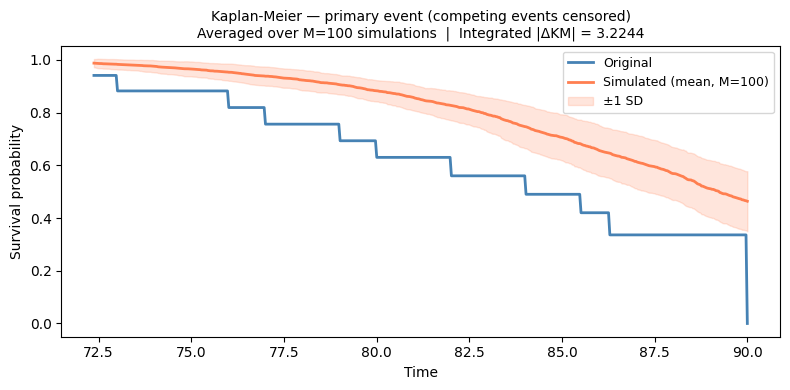

Integrated |KM difference|: 3.2244

Event-type rates (original):
  censored: 0.353
  primary event: 0.647

Event-type rates (simulated, mean ± std over M=100):
  censored: 0.593 ± 0.079
  primary event: 0.407 ± 0.079
  competing event: 0.000 ± 0.000


In [33]:

# One row per patient — original
surv_orig = df.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']].dropna().copy()
surv_orig['event'] = (surv_orig['EVENT_BOOL'] == 1).astype(int)

# Common time grid
t_min = surv_orig['EVENT_TIME'].min()
t_max = surv_orig['EVENT_TIME'].max()
t_grid = np.linspace(t_min, t_max, 500)

# KM for original
kmf_orig = KaplanMeierFitter()
kmf_orig.fit(surv_orig['EVENT_TIME'], surv_orig['event'])
s_orig = kmf_orig.survival_function_at_times(t_grid).values

# KM for each simulation → collect survival curves on the common grid
s_sims = []
event_rates = {k: [] for k in [0, 1, 2]}

for df_s in sims:
    surv_s = df_s.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']].dropna().copy()
    surv_s['event'] = (surv_s['EVENT_BOOL'] == 1).astype(int)
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(surv_s['EVENT_TIME'], surv_s['event'])
    s_sims.append(kmf_s.survival_function_at_times(t_grid).values)
    vc = surv_s['EVENT_BOOL'].value_counts(normalize=True)
    for k in [0, 1, 2]:
        event_rates[k].append(vc.get(k, 0.0))

s_sims    = np.array(s_sims)          # (M, 500)
s_sim_mean = s_sims.mean(axis=0)
s_sim_std  = s_sims.std(axis=0)

integrated_diff = np.trapz(np.abs(s_orig - s_sim_mean), t_grid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, s_orig, color='steelblue', lw=2, label='Original')
ax.plot(t_grid, s_sim_mean, color='coral', lw=2, label=f'Simulated (mean, M={M})')
ax.fill_between(t_grid, s_sim_mean - s_sim_std, s_sim_mean + s_sim_std,
                alpha=0.2, color='coral', label='±1 SD')
ax.set_title(
    f'Kaplan-Meier — primary event (competing events censored)\n'
    f'Averaged over M={M} simulations  |  Integrated |ΔKM| = {integrated_diff:.4f}',
    fontsize=10
)
ax.set_xlabel('Time')
ax.set_ylabel('Survival probability')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Integrated |KM difference|:', round(integrated_diff, 4))

# Event-type breakdown
names = {0: 'censored', 1: 'primary event', 2: 'competing event'}
vc_orig = surv_orig['EVENT_BOOL'].value_counts(normalize=True).sort_index()
print('\nEvent-type rates (original):')
for k, v in vc_orig.items():
    print(f"  {names.get(k, k)}: {v:.3f}")
print(f'\nEvent-type rates (simulated, mean ± std over M={M}):')
for k in [0, 1, 2]:
    vals = event_rates[k]
    print(f"  {names[k]}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")


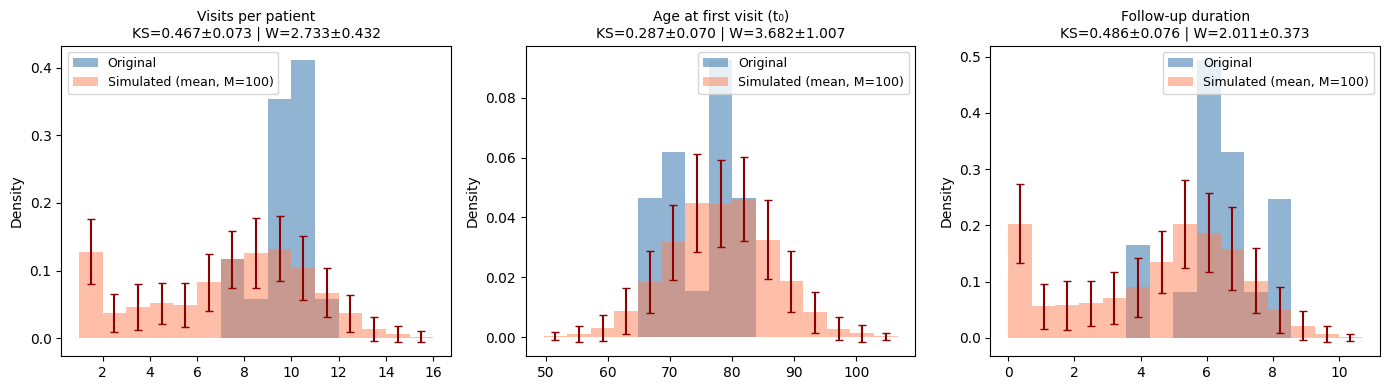

,Metric,Mean (orig),Mean (sim avg),SD (orig),SD (sim avg)
0,n_visits,9.235,6.825,1.059,3.348
1,age_first_visit,75.064,78.187,5.578,7.962
2,followup_duration,6.419,4.463,1.168,2.514


In [34]:

def visit_process_metrics_avg(df, sims):
    n_orig  = df.groupby('ID').size().values
    t0_orig = df.groupby('ID')['TIME'].min().values
    fu_orig = df.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min()).values

    # Per-simulation distributions
    n_per, t0_per, fu_per = [], [], []
    for df_s in sims:
        n_per.append(df_s.groupby('ID').size().values)
        t0_per.append(df_s.groupby('ID')['TIME'].min().values)
        fu_per.append(df_s.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min()).values)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metrics = {}

    for ax, (a, b_list, title) in zip(axes, [
        (n_orig,  n_per,  'Visits per patient'),
        (t0_orig, t0_per, 'Age at first visit (t₀)'),
        (fu_orig, fu_per, 'Follow-up duration'),
    ]):
        # Bin edges spanning the full range of original + all simulations
        all_vals = np.concatenate([a] + b_list)
        bin_edges = np.linspace(all_vals.min(), all_vals.max(), 16)  # 15 bins

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Original histogram
        counts, _ = np.histogram(a, bins=bin_edges, density=True)
        ax.bar(bin_centers, counts, width=np.diff(bin_edges),
               alpha=0.6, label='Original', color='steelblue')

        # Per-sim density on same bins → mean ± std
        all_densities = np.array([
            np.histogram(b, bins=bin_edges, density=True)[0] for b in b_list
        ])
        mean_d = all_densities.mean(axis=0)
        std_d  = all_densities.std(axis=0)
        ax.bar(bin_centers, mean_d, width=np.diff(bin_edges),
               alpha=0.5, label=f'Simulated (mean, M={len(sims)})', color='coral')
        ax.errorbar(bin_centers, mean_d, yerr=std_d, fmt='none', color='darkred', capsize=3)

        # Scalar metrics averaged across simulations
        ks_vals   = [ks_2samp(a, b)[0]          for b in b_list]
        wass_vals = [wasserstein_distance(a, b)  for b in b_list]
        ks_m,   ks_s   = np.mean(ks_vals),   np.std(ks_vals)
        wass_m, wass_s = np.mean(wass_vals), np.std(wass_vals)

        ax.set_title(f'{title}\nKS={ks_m:.3f}±{ks_s:.3f} | W={wass_m:.3f}±{wass_s:.3f}', fontsize=10)
        ax.legend(fontsize=9)
        ax.set_ylabel('Density')
        metrics[title] = {
            'KS_mean': round(ks_m, 4),   'KS_std': round(ks_s, 4),
            'W_mean':  round(wass_m, 4), 'W_std':  round(wass_s, 4),
        }

    plt.tight_layout()
    plt.show()

    # Summary table
    summary = pd.DataFrame({
        'Metric':         ['n_visits', 'age_first_visit', 'followup_duration'],
        'Mean (orig)':    [n_orig.mean(),  t0_orig.mean(),  fu_orig.mean()],
        'Mean (sim avg)': [np.mean([b.mean() for b in n_per]),
                           np.mean([b.mean() for b in t0_per]),
                           np.mean([b.mean() for b in fu_per])],
        'SD (orig)':      [n_orig.std(),   t0_orig.std(),   fu_orig.std()],
        'SD (sim avg)':   [np.mean([b.std() for b in n_per]),
                           np.mean([b.std() for b in t0_per]),
                           np.mean([b.std() for b in fu_per])],
    }).round(3)
    return metrics, summary

visit_metrics, visit_summary = visit_process_metrics_avg(df, sims)
display(visit_summary)


## Feature Correlation Structure

The joint model simulates correlated multivariate trajectories. Comparing the pairwise correlation matrices checks whether the inter-feature dependence structure is preserved.


Max  |Δcorr| (M=100 avg): 0.1741
Mean |Δcorr| (M=100 avg): 0.0976


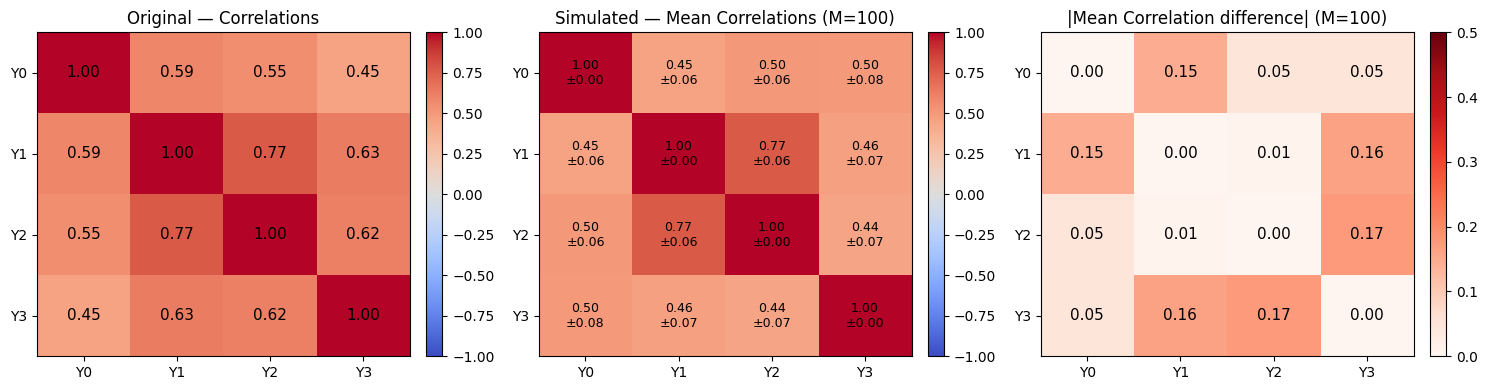

In [35]:

corr_orig = df[feat_cols].corr()

# Per-simulation correlation matrices → mean and std
corr_mats = np.array([s[feat_cols].corr().values for s in sims])   # (M, 4, 4)
corr_sim_mean = corr_mats.mean(axis=0)
corr_sim_std  = corr_mats.std(axis=0)
corr_diff_mean = np.abs(corr_orig.values - corr_sim_mean)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, corr, title, cmap, vmin, vmax in [
    (axes[0], corr_orig.values, 'Original — Correlations',                    'coolwarm', -1, 1),
    (axes[1], corr_sim_mean,    f'Simulated — Mean Correlations (M={M})',      'coolwarm', -1, 1),
    (axes[2], corr_diff_mean,   f'|Mean Correlation difference| (M={M})',      'Reds',      0, 0.5),
]:
    im = ax.imshow(corr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(feat_cols))); ax.set_xticklabels(feat_cols)
    ax.set_yticks(range(len(feat_cols))); ax.set_yticklabels(feat_cols)
    for i in range(len(feat_cols)):
        for j in range(len(feat_cols)):
            val = corr[i, j]
            # Also show ±std for the mean-correlation panel
            if ax is axes[1]:
                ax.text(j, i, f'{val:.2f}\n±{corr_sim_std[i,j]:.2f}',
                        ha='center', va='center', fontsize=9)
            else:
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

upper = np.triu_indices(len(feat_cols), k=1)
print(f'Max  |Δcorr| (M={M} avg): {corr_diff_mean[upper].max():.4f}')
print(f'Mean |Δcorr| (M={M} avg): {corr_diff_mean[upper].mean():.4f}')

plt.tight_layout()
plt.show()


## Competing Events — Cumulative Incidence Functions

With competing events, the Kaplan-Meier estimator is biased; the proper tool is the **Aalen-Johansen** estimator, which gives the cumulative incidence function (CIF) for each cause.


In [ ]:

from lifelines import AalenJohansenFitter

# Common time grid (from original)
t_grid_cif = np.linspace(surv_orig['EVENT_TIME'].min(), surv_orig['EVENT_TIME'].max(), 200)

def get_cif_values(surv_df, event_of_interest, t_grid):
    ajf = AalenJohansenFitter(calculate_variance=False)
    ajf.fit(surv_df['EVENT_TIME'], surv_df['EVENT_BOOL'], event_of_interest=event_of_interest)
    return ajf.cumulative_density_at_times(t_grid).values

# CIFs for the original
cif1_orig = get_cif_values(surv_orig, 1, t_grid_cif)
cif2_orig = get_cif_values(surv_orig, 2, t_grid_cif)

# CIFs for each simulation
cif1_sims, cif2_sims = [], []
for df_s in sims:
    surv_s = df_s.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']].dropna()
    cif1_sims.append(get_cif_values(surv_s, 1, t_grid_cif))
    cif2_sims.append(get_cif_values(surv_s, 2, t_grid_cif))

cif1_sims = np.array(cif1_sims)   # (M, 200)
cif2_sims = np.array(cif2_sims)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cif_orig, cif_arr, label in [
    (axes[0], cif1_orig, cif1_sims, 'Primary event'),
    (axes[1], cif2_orig, cif2_sims, 'Competing event'),
]:
    cif_mean = cif_arr.mean(axis=0)
    cif_std  = cif_arr.std(axis=0)

    ax.plot(t_grid_cif, cif_orig, color='steelblue', lw=2, label='Original')
    ax.plot(t_grid_cif, cif_mean, color='coral',     lw=2, label=f'Simulated (mean, M={M})')
    ax.fill_between(t_grid_cif, cif_mean - cif_std, cif_mean + cif_std,
                    alpha=0.2, color='coral', label='±1 SD')

    diff = np.trapz(np.abs(cif_orig - cif_mean), t_grid_cif)
    ax.set_title(f'CIF — {label}\nIntegrated |diff| = {diff:.4f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Cumulative Incidence')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
